## Introduction

This project explores how daily factors such as sleep, noise level, routine changes, antecedents, and environmental setting relate to the occurrence and intensity of problem behaviour in children with autism. By analyzing these variables, the goal is to identify meaningful patterns that can inform behavioural insights and support future predictive modelling.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/aba_behavior_synthetic.csv')

## Data Overview

This synthetic dataset contains 6000 observations with 13 variables describing daily factors and behavioural outcomes for children with autism. The features include sleep duration, screen time, sugar intake, noise levels, routine changes, antecedent types, and environmental settings. The target variables are whether problem behaviour occurred and the recorded intensity of that behaviour. This section provides an initial look at the structure and characteristics of the dataset.



In [4]:
df.head()

,session_id,date,client_id,hours_slept,screen_time_hours,sugar_intake,noise_level,routine_change,setting,antecedent,session_period,behavior_occurred,behavior_type,behavior_intensity
0,S000001,2024-01-01,1027,9.5,3.5,3,8,0,School,Denied Access,Midday,1,Property Destruction,4
1,S000002,2024-01-01,1046,5.8,2.0,4,8,0,School,Peer Conflict,Evening,0,NaN,0
2,S000003,2024-01-01,1015,8.2,3.1,2,3,0,Home,Demand,Morning,1,Property Destruction,3
3,S000004,2024-01-01,1025,6.8,1.9,3,8,0,School,Demand,Afternoon,1,Property Destruction,1
4,S000005,2024-01-01,1012,8.4,4.0,0,2,0,Home,Demand,Evening,1,Aggression,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_id          6000 non-null   str    
 1   date                6000 non-null   str    
 2   client_id           6000 non-null   int64  
 3   hours_slept         6000 non-null   float64
 4   screen_time_hours   6000 non-null   float64
 5   sugar_intake        6000 non-null   int64  
 6   noise_level         6000 non-null   int64  
 7   routine_change      6000 non-null   int64  
 8   setting             6000 non-null   str    
 9   antecedent          6000 non-null   str    
 10  session_period      6000 non-null   str    
 11  behavior_occurred   6000 non-null   int64  
 12  behavior_type       2973 non-null   str    
 13  behavior_intensity  6000 non-null   int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 656.4 KB


The `df.info` method verifies that the data contains 6000 entries.

In [6]:
df.describe(include='all')

,session_id,date,client_id,hours_slept,screen_time_hours,sugar_intake,noise_level,routine_change,setting,antecedent,session_period,behavior_occurred,behavior_type,behavior_intensity
count,6000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000,6000,6000.000000,2973,6000.00000
unique,6000,241,NaN,NaN,NaN,NaN,NaN,NaN,3,5,4,NaN,5,NaN
top,S000001,2024-01-14,NaN,NaN,NaN,NaN,NaN,NaN,School,Transition,Evening,NaN,Elopement,NaN
freq,1,39,NaN,NaN,NaN,NaN,NaN,NaN,2051,1247,1536,NaN,619,NaN
mean,NaN,NaN,1029.317667,8.026033,2.517600,1.994500,5.677000,0.258500,NaN,NaN,NaN,0.495500,NaN,1.47850
std,NaN,NaN,17.401692,1.795982,1.213471,1.413554,2.306778,0.437847,NaN,NaN,NaN,0.500021,NaN,1.65126
min,NaN,NaN,1000.000000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,0.00000
25%,NaN,NaN,1014.000000,6.800000,1.700000,1.000000,4.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,0.00000
50%,NaN,NaN,1029.000000,8.000000,2.500000,2.000000,6.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,0.00000
75%,NaN,NaN,1045.000000,9.300000,3.300000,3.000000,7.000000,1.000000,NaN,NaN,NaN,1.000000,NaN,3.00000


With the `df.describe()` method, we can see important summary stats of the data. For example, the top behaviour type was 'Elopement.'

In [7]:
df.isna().sum()

session_id               0
date                     0
client_id                0
hours_slept              0
screen_time_hours        0
sugar_intake             0
noise_level              0
routine_change           0
setting                  0
antecedent               0
session_period           0
behavior_occurred        0
behavior_type         3027
behavior_intensity       0
dtype: int64

The data contains 3027 missing values for the `behavior_type` column, this indicates that behaviour did not occur for those entries. There are no missing values in the other columns.

## Target Distribution


In [8]:
df['behavior_occurred'].value_counts(normalize=True)

behavior_occurred
0    0.5045
1    0.4955
Name: proportion, dtype: float64

The target variable in this dataset is whether problem behaviour occurred on a given day. The distribution is balanced, with problem behaviour occurring in approximately 50% of entries.

## Feature Distribution

To understand the general characteristics of the dataset, I examine the distributions of key numerical features such as sleep hours, screen time, noise level, and behaviour intensity. Exploring these distributions helps identify typical ranges, potential outliers, and meaningful patterns that may relate to problem behaviour. This step provides foundational context for interpreting later relationship analyses.


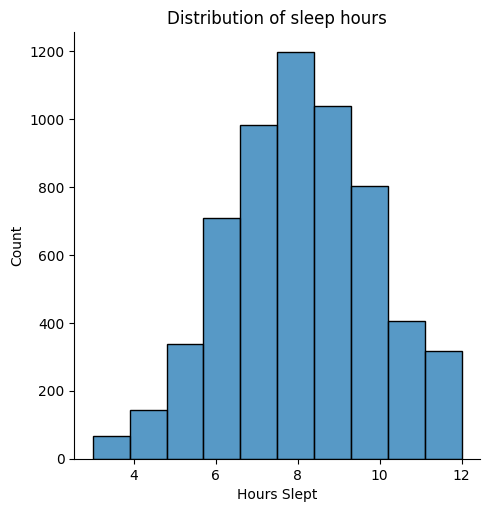

In [9]:
sns.displot(data=df, x='hours_slept', kind='hist', bins=10)
plt.xlabel('Hours Slept')
plt.title('Distribution of sleep hours')
plt.show()


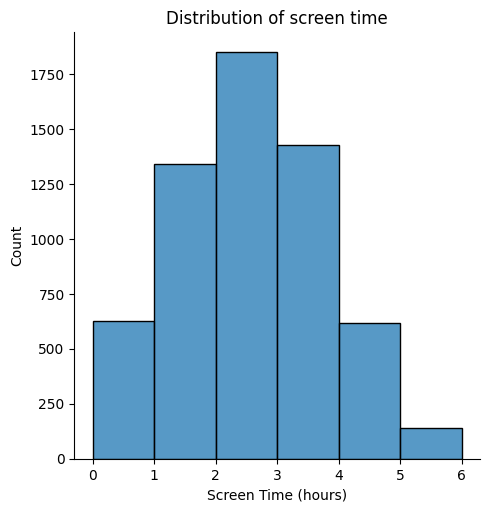

In [10]:
sns.displot(data=df, x='screen_time_hours', kind='hist', bins=6)
plt.xlabel('Screen Time (hours)')
plt.title('Distribution of screen time')
plt.show()


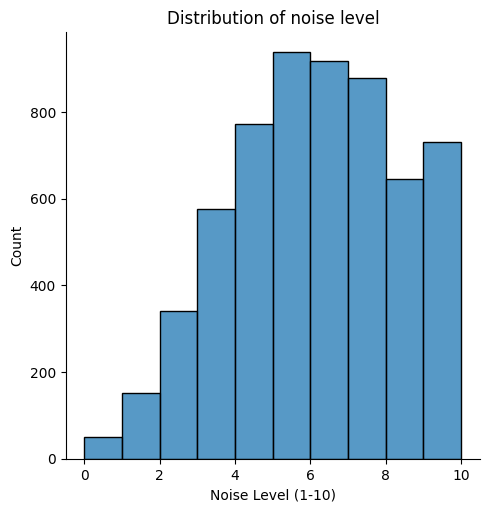

In [11]:
sns.displot(data=df, x='noise_level', kind='hist', bins=10)
plt.xlabel('Noise Level (1-10)')
plt.title('Distribution of noise level')
plt.show()


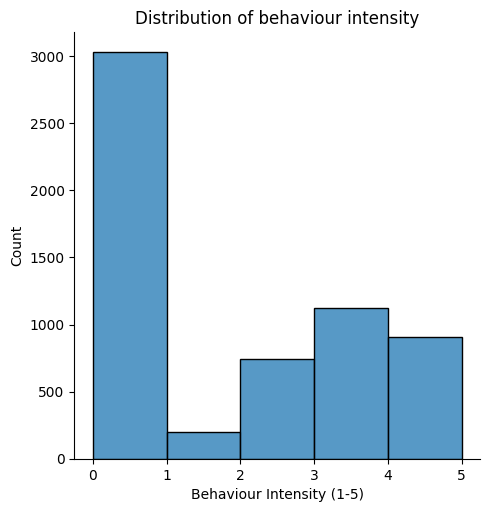

In [12]:
sns.displot(data=df, x='behavior_intensity', kind='hist', bins=5)
plt.xlabel('Behaviour Intensity (1-5)')
plt.title('Distribution of behaviour intensity')
plt.show()


## Sleep and Problem Behaviour
Sleep is one of the most clinically meaningful variables when thinking about problem behaviour. Reduced sleep is often linked to lower frustration tolerance, difficulty with transitions, and greater likelihood of challenging behaviour.

In this section, I group nights of sleep into simple buckets (e.g., less than 6 hours, 6–8 hours, etc.) and compare the **rate of problem behaviour** between these groups. This helps answer a practical question:

> Are problem behaviours more likely to occur on days following poor sleep?

In [13]:
df['sleep_bucket'] = pd.cut(
    df['hours_slept'],
    bins=[0, 6, 8, 10, 24],
    labels=['<6', '6–8', '8–10', '>10'],
    right=True,
    include_lowest=True,
)

df['sleep_bucket'].value_counts().sort_index()

sleep_bucket
<6       817
6–8     2237
8–10    2156
>10      790
Name: count, dtype: int64

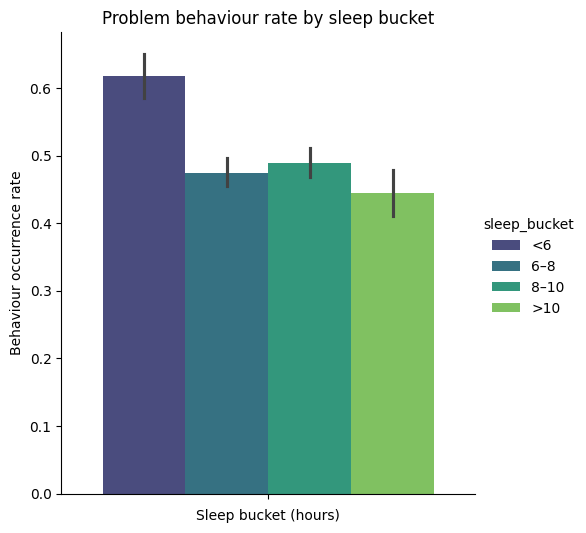

In [14]:
sns.catplot(data=df, hue='sleep_bucket', y='behavior_occurred', kind='bar', palette='viridis')
plt.xlabel('Sleep bucket (hours)')
plt.ylabel('Behaviour occurrence rate')
plt.title('Problem behaviour rate by sleep bucket')
plt.show()

In [15]:
df.groupby('sleep_bucket')['behavior_occurred'].mean().sort_values(ascending=False)

sleep_bucket
<6      0.618115
8–10    0.489332
6–8     0.474743
>10     0.444304
Name: behavior_occurred, dtype: float64

### Interpretation: Sleep and Problem Behaviour

The results show a clear relationship between the amount of sleep and the likelihood of problem behaviour:

- Children who slept less than **6 hours** had the highest behaviour rate (**61.8%**), indicating a very strong likelihood of behavioural challenges following severely reduced sleep.
- The **8–10 hour** group also showed a high behaviour rate (**48.9%**), suggesting that even moderate sleep reduction may impact behaviour.
- Behaviour rates decreased in the **6–8 hour** range (**47.4%**), indicating improved regulation with more adequate sleep.
- The lowest behaviour rate was observed in the **>10 hour** group (**44.4%**), showing that extended or well-rested sleep was associated with significantly fewer behavioural incidents.

Overall, these results suggest that **reduced sleep is associated with a higher probability of problem behaviour**. The pattern is consistent and shows a meaningful downward trend as sleep duration increases. This aligns with clinical expectations in ABA and developmental psychology: poor sleep can reduce emotional regulation, increase irritability, and raise the likelihood of challenging behaviour the following day.


## Antecedent and Problem Behaviour

Antecedents describe what happens immediately before a behaviour occurs and are one of the most important components of ABA analysis. Certain antecedents, such as transitions, denied access, or task demands, are known to incease the risk of challenging behaviour.

In this section, I examine how different antecedent types relate to the probability of problem behaviour occurring. This helps identify which triggers are associated with higher behavioural risk and provides insight into proactive planning for sessions.


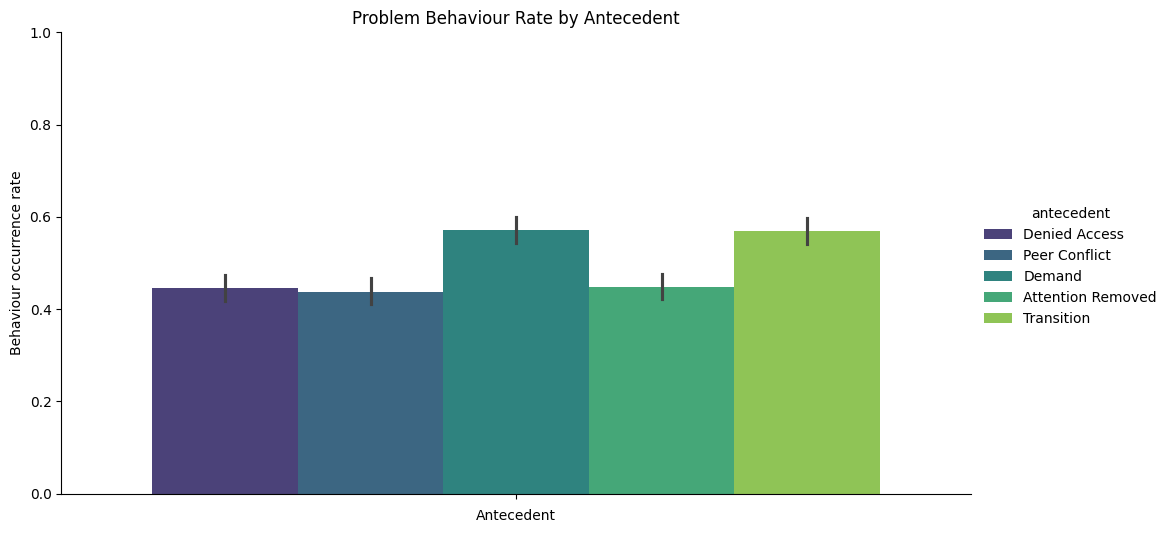

In [16]:
sns.catplot(data=df, hue='antecedent', y='behavior_occurred', kind='bar',
             palette='viridis', aspect=2)
plt.xlabel('Antecedent')
plt.ylabel('Behaviour occurrence rate')
plt.title('Problem Behaviour Rate by Antecedent')
plt.ylim(0, 1)
plt.show()

In [17]:
df.groupby('antecedent')['behavior_occurred'].mean().sort_values(ascending=False)


antecedent
Demand               0.572500
Transition           0.568565
Attention Removed    0.448653
Denied Access        0.444728
Peer Conflict        0.438183
Name: behavior_occurred, dtype: float64

### Interpretation: Antecedents and Problem Behaviour

The results show clear differences in behaviour likelihood across antecedent types:

- **Demand** had the highest behaviour rate (**57.2%**), indicating that task-related demands are the strongest trigger in this dataset. This is consistent with escape-maintained behaviours commonly observed during instructional tasks.
- **Transition** showed the second-highest behaviour rate (**56.8%**), reflecting the difficulty many children experience when switching between activities or environments.
- **Denied Access, Attention Removed, and Peer Conflict** showed lower behaviour rates at **48%**.

Overall, these results highlight that antecedents involving **demands and transitions** present the highest behavioural risk. These patterns are well-aligned with ABA clinical observations, emphasizing the importance of:
- priming and visual supports during transitions,  
- demand fading and choice-making,  
- and proactive reinforcement strategies when restricting access.  

Understanding which antecedents carry the most risk helps guide intervention planning and predict when challenging behaviour is most likely to occur.


## Setting and Problem Behaviour

The environment of the child significantly impact the risk of behaviour occurence. Children may respond differently in the home, clinic, or school setting due to differences in structure, expectations, sensory load, and social demands.

In this section, I examine whether certain settings are associated with higher rates of problem behaviour.


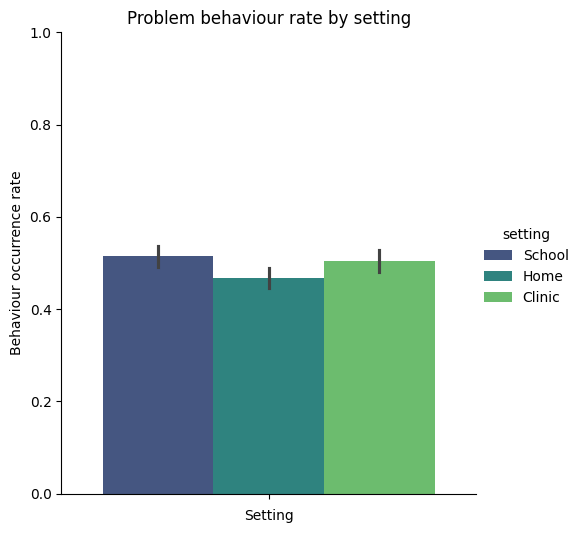

In [18]:
sns.catplot(data=df, hue='setting', y='behavior_occurred', kind='bar', palette='viridis')
plt.xlabel('Setting')
plt.ylabel('Behaviour occurrence rate')
plt.title('Problem behaviour rate by setting')
plt.ylim(0, 1)
plt.show()

In [19]:
df.groupby('setting')['behavior_occurred'].mean().sort_values(ascending=False)

setting
School    0.514383
Clinic    0.504357
Home      0.467467
Name: behavior_occurred, dtype: float64

### Interpretation: Setting and Problem Behaviour

There are clear differences in behaviour likelihood across the three settings:

- **School** showed the highest behaviour rate (**51.4%**), suggesting that the structured, task-heavy, and socially demanding school environment may place greater stress on learners. Increased transitions, academic expectations, and peer interactions could all contribute to higher behavioural likelihood.
- **Clinic** had the second-highest behaviour rate (**50.4%**). Although clinics provide therapeutic structure, sessions often involve targeted demands, skill acquisition tasks, and less access to preferred items, which may elevate behavioural risk.
- **Home** showed the lowest behaviour rate (**46.7%**). Home environments typically offer more familiarity, fewer external demands, and greater access to reinforcement, which may help reduce challenging behaviour.

Overall, these results indicate that **more structured or demanding environments (School and Clinic)** are associated with higher risk of problem behaviour, while the **Home setting** appears somewhat protective. This aligns with common ABA observations and reinforces the importance of considering environmental context when assessing behaviour trends or planning interventions.


## Noise Level and Behaviour Intensity

Noise level contributes to sensory load and can affect regulation, especially for children with sensory sensitivities. Here, I explore whether higher noise levels are associated with increased behaviour intensity.


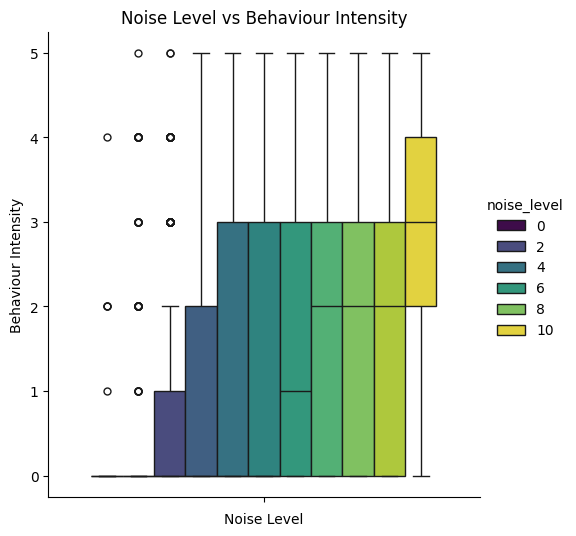

In [20]:
sns.catplot(data=df, hue='noise_level', y='behavior_intensity', kind='box', palette='viridis')
plt.title('Noise Level vs Behaviour Intensity')
plt.xlabel('Noise Level')
plt.ylabel('Behaviour Intensity')
plt.show()

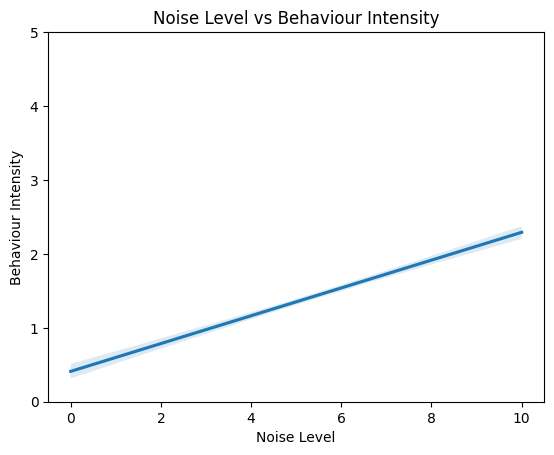

In [21]:
sns.regplot(data=df, x='noise_level', y='behavior_intensity', scatter=False)
plt.title('Noise Level vs Behaviour Intensity')
plt.xlabel('Noise Level')
plt.ylabel('Behaviour Intensity')
plt.ylim(0,5)
plt.show()

### Interpretation: Noise Level and Behaviour Intensity

The boxplot and regression line both show a **clear positive relationship** between environmental noise levels and behaviour intensity. As noise increases, the intensity of challenging behaviour tends to rise in a consistent, almost linear pattern.

At lower noise levels (0–2), behaviour intensity is generally low, with most points clustering around mild intensity scores. As noise increases into the mid-range (5–7), intensity values become more variable, and moderate behaviours are more common. At the highest noise levels (8–10), behaviour intensities reach their highest observed values in the dataset, with several points approaching the upper end of the severity scale.

This pattern aligns with clinical expectations for children with autism, many of whom experience sensory sensitivities. Elevated auditory stimulation can increase stress, reduce self-regulation capacity, and lower tolerance for demands or changes. The upward trend in the regression line suggests that **noise level is a meaningful predictor of behaviour intensity**, and may warrant monitoring in behaviour plans, classroom environments, or clinic settings.

Overall, the analysis indicates that **higher noise levels are associated with more intense behavioural episodes**, highlighting the importance of managing sensory environments in ABA programming.


## Summary of Insights

- Sleep duration showed a strong negative relationship with behaviour: less sleep was associated with higher behaviour likelihood.
- Demand and Transition antecedents produced the highest behaviour rates, aligning with common ABA triggers.
- Setting analysis showed differences in behavioural likelihood between environments.
- Noise level appeared to have a positive relationship with behaviour intensity.

These insights provide a strong foundation for future modelling and deeper analysis.


## Next Steps

This EDA highlights several variables that appear strongly linked to problem behaviour, including sleep, antecedents, setting, and noise level. Future steps may include:

- Building a predictive model for behaviour occurrence.
- Modeling behaviour intensity using regression.
- Evaluating feature importance to quantify which variables contribute most.
- Exploring time-based trends or client-specific patterns.

These steps will build on the insights from this analysis and move toward more advanced modeling.
